# 대한민국 출생아 수 및 합계출산율 데이터 클렌징과 다각도 심층 분석

본 노트북은 통계청 인구동향조사 데이터(`출생아수__합계출산율__자연증가_등_20240726084835.xlsx`)를 활용하여,
1. **데이터 클렌징**: 행/열 전치, 연도 및 컬럼명 정제, 수치형 데이터 타입 변환
2. **다각도 심층 분석**: 기초통계, 반세기(1970 vs 2023) 변화율, 10년 단위(연대별) 추이, 인구학적 변곡점, 상관관계
3. **한글 폰트 지원 시각화**: 연도별 출생아수 라인 그래프 및 4분할 종합 분석 대시보드 시각화
를 수행합니다.

## 1. 환경 설정 및 한글 폰트 세팅
- Windows 환경에서 한글 깨짐 방지를 위해 `Malgun Gothic`(맑은 고딕) 폰트를 적용합니다.
- 마이너스 부호(`-`)가 네모(□)로 깨지는 현상을 방지하기 위해 `axes.unicode_minus = False`를 설정합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 한글 폰트 및 음수 부호 깨짐 방지 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 로드 및 한글 폰트 설정 완료!")

라이브러리 로드 및 한글 폰트 설정 완료!


## 2. 데이터 불러오기 및 원본 구조 확인

In [2]:
file_path = "출생아수__합계출산율__자연증가_등_20240726084835.xlsx"
df_raw = pd.read_excel(file_path, sheet_name="데이터")
print("원본 데이터 크기:", df_raw.shape)
df_raw.head(6)

원본 데이터 크기: (6, 55)


c:\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,기본항목별,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023 p)
0,출생아수(명),1006645.00,1024773.00,952780.00,965521.00,922823.00,874030.00,796331.0,825339.00,750728.00,...,435435.000,438420.000,406243.000,357771.000,326822.000,302676.000,272337.000,260562.000,249186.000,230000.00
1,자연증가건수(명),748056.00,787245.00,742709.00,698061.00,674016.00,603373.00,529474.0,576085.00,498430.00,...,167743.000,162525.000,125416.000,72237.000,28002.000,7566.000,-32611.000,-57118.000,-123753.000,-122800.00
2,조출생률(천명당),31.20,31.20,28.40,28.30,26.60,24.80,22.2,22.70,20.30,...,8.600,8.600,7.900,7.000,6.400,5.900,5.300,5.100,4.900,4.50
3,자연증가율(천명당),23.20,23.90,22.20,20.50,19.40,17.10,14.8,15.80,13.50,...,3.300,3.200,2.500,1.400,0.500,0.100,-0.600,-1.100,-2.400,-2.40
4,합계출산율(명),4.53,4.54,4.12,4.07,3.77,3.43,3.0,2.99,2.64,...,1.205,1.239,1.172,1.052,0.977,0.918,0.837,0.808,0.778,0.72
5,출생성비(명),109.50,109.00,109.50,104.60,109.40,112.40,110.7,104.20,111.30,...,105.300,105.300,105.000,106.300,105.400,105.500,104.800,105.100,104.700,105.10


## 3. 데이터 클렌징 (Data Cleansing)
1. **전치(Transpose)**: 연도를 행 인덱스로, 지표명을 컬럼으로 재배치합니다.
2. **연도 정제**: `2023 p)`와 같은 잠정치 표기를 제거하고 정수형(`int`) 연도로 변환합니다.
3. **컬럼명 정규화**: 괄호 속 단위(`(명)`, `(천명당)`)를 분리하여 간결하게 정제합니다.
4. **데이터 타입 변환**: 인원/건수는 `int64`, 비율/성비는 `float64`로 변환합니다.
5. **파생변수 추가**: `출생아수_만명`, `출생아수_증감률(%)`, `연대` 구분 컬럼을 생성합니다.

In [3]:
# 1) 전치
df = df_raw.set_index("기본항목별").T

# 2) 연도 인덱스 정제
df.index = df.index.astype(str).str.extract(r"(\d{4})")[0].astype(int)
df.index.name = "연도"

# 3) 컬럼명 정제
df = df.rename(columns={col: col.split("(")[0].strip() for col in df.columns})

# 4) 데이터 타입 변환
type_dict = {
    "출생아수": "int64",
    "자연증가건수": "int64",
    "조출생률": "float64",
    "자연증가율": "float64",
    "합계출산율": "float64",
    "출생성비": "float64"
}
df = df.astype(type_dict)

# 5) 파생변수 생성
df["출생아수_만명"] = df["출생아수"] / 10000.0
df["출생아수_증감률"] = df["출생아수"].pct_change() * 100.0
df["연대"] = (df.index // 10 * 10).astype(str) + "년대"

# 정제 결과 CSV 및 Excel 저장
df.to_csv("cleaned_birth_data.csv", encoding="utf-8-sig")
df.to_excel("cleaned_birth_data.xlsx")

print("정제 완료! 데이터 정보:")
df.info()

정제 완료! 데이터 정보:
<class 'pandas.DataFrame'>
Index: 54 entries, 1970 to 2023
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   출생아수      54 non-null     int64  
 1   자연증가건수    54 non-null     int64  
 2   조출생률      54 non-null     float64
 3   자연증가율     54 non-null     float64
 4   합계출산율     54 non-null     float64
 5   출생성비      54 non-null     float64
 6   출생아수_만명   54 non-null     float64
 7   출생아수_증감률  53 non-null     float64
 8   연대        54 non-null     str    
dtypes: float64(6), int64(2), str(1)
memory usage: 4.2 KB


In [4]:
# 클렌징된 데이터 확인
display(df.head())
display(df.tail())

기본항목별,출생아수,자연증가건수,조출생률,자연증가율,합계출산율,출생성비,출생아수_만명,출생아수_증감률,연대
연도,,,,,,,,,
1970,1006645,748056,31.2,23.2,4.53,109.5,100.6645,NaN,1970년대
1971,1024773,787245,31.2,23.9,4.54,109.0,102.4773,1.800833,1970년대
1972,952780,742709,28.4,22.2,4.12,109.5,95.2780,-7.025263,1970년대
1973,965521,698061,28.3,20.5,4.07,104.6,96.5521,1.337245,1970년대
1974,922823,674016,26.6,19.4,3.77,109.4,92.2823,-4.422276,1970년대


기본항목별,출생아수,자연증가건수,조출생률,자연증가율,합계출산율,출생성비,출생아수_만명,출생아수_증감률,연대
연도,,,,,,,,,
2019,302676,7566,5.9,0.1,0.918,105.5,30.2676,-7.388120,2010년대
2020,272337,-32611,5.3,-0.6,0.837,104.8,27.2337,-10.023590,2020년대
2021,260562,-57118,5.1,-1.1,0.808,105.1,26.0562,-4.323687,2020년대
2022,249186,-123753,4.9,-2.4,0.778,104.7,24.9186,-4.365947,2020년대
2023,230000,-122800,4.5,-2.4,0.720,105.1,23.0000,-7.699469,2020년대


## 4. pandas 다각도 데이터 분석 (Multi-angle Analysis)
### (1) 주요 지표 기초 기술통계량

In [5]:
df[["출생아수", "합계출산율", "자연증가건수", "조출생률", "출생성비"]].describe().round(2)

기본항목별,출생아수,합계출산율,자연증가건수,조출생률,출생성비
count,54.00,54.00,54.00,54.00,54.00
mean,614286.28,1.82,356348.09,14.70,108.49
std,208108.79,0.99,226489.30,7.06,3.12
min,230000.00,0.72,-123753.00,4.50,104.20
25%,455292.25,1.19,209165.00,9.25,105.70
50%,637725.00,1.53,396266.00,14.75,108.20
75%,745715.50,1.98,497451.50,18.65,110.10
max,1024773.00,4.54,787245.00,31.20,116.50


### (2) 1970년 vs 2023년 반세기 변화 비교

In [6]:
y1970 = df.loc[1970]
y2023 = df.loc[2023]

diff_birth = y2023["출생아수"] - y1970["출생아수"]
pct_birth = (diff_birth / y1970["출생아수"]) * 100
diff_tfr = y2023["합계출산율"] - y1970["합계출산율"]
pct_tfr = (diff_tfr / y1970["합계출산율"]) * 100

compare_df = pd.DataFrame({
    "1970년": [f"{y1970['출생아수']:,}명", f"{y1970['합계출산율']:.2f}명", f"+{y1970['자연증가건수']:,}명", f"{y1970['조출생률']:.1f}명"],
    "2023년": [f"{y2023['출생아수']:,}명", f"{y2023['합계출산율']:.3f}명", f"{y2023['자연증가건수']:,}명", f"{y2023['조출생률']:.1f}명"],
    "변화량(증감)": [f"{diff_birth:,}명", f"{diff_tfr:.3f}명", f"{y2023['자연증가건수'] - y1970['자연증가건수']:,}명", f"{y2023['조출생률'] - y1970['조출생률']:.1f}명"],
    "증감율(%)": [f"{pct_birth:.2f}%", f"{pct_tfr:.2f}%", "-", f"{(y2023['조출생률'] - y1970['조출생률']) / y1970['조출생률'] * 100:.2f}%"]
}, index=["출생아 수", "합계출산율", "자연증가건수", "조출생률"])
compare_df

,1970년,2023년,변화량(증감),증감율(%)
출생아 수,"1,006,645명","230,000명","-776,645명",-77.15%
합계출산율,4.53명,0.720명,-3.810명,-84.11%
자연증가건수,"+748,056명","-122,800명","-870,856명",-
조출생률,31.2명,4.5명,-26.7명,-85.58%


### (3) 연대별(10년 단위) 평균 지표 분석

In [7]:
decade_summary = df.groupby("연대")[["출생아수", "합계출산율", "자연증가건수", "조출생률", "출생성비"]].agg({
    "출생아수": ["mean", "min", "max"],
    "합계출산율": "mean",
    "자연증가건수": "mean",
    "출생성비": "mean"
}).round(2)
decade_summary

기본항목별        출생아수                  합계출산율    자연증가건수    출생성비
             mean     min      max  mean      mean    mean
연대                                                        
1970년대  898163.90  750728  1024773  3.60  648013.2  108.70
1980년대  721036.60  623831   867409  1.95  476305.1  108.97
1990년대  687060.40  620668   730678  1.60  445162.1  112.55
2000년대  496695.70  438707   640089  1.21  250462.4  108.02
2010년대  412980.80  302676   484550  1.15  137965.1  105.64
2020년대  253021.25  230000   272337  0.79  -84070.5  104.92

### (4) 대한민국 인구학적 주요 변곡점 및 마일스톤

In [8]:
milestones = {
    "역대 최다 출생아 연도": f"{df['출생아수'].idxmax()}년 ({df['출생아수'].max():,}명)",
    "역대 최저 출생아 연도": f"{df['출생아수'].idxmin()}년 ({df['출생아수'].min():,}명)",
    "인구대체수준(2.1명) 최초 붕괴": f"{df[df['합계출산율'] < 2.1].index[0]}년 ({df.loc[df[df['합계출산율'] < 2.1].index[0], '합계출산율']:.2f}명)",
    "초저출산사회(1.3명) 최초 진입": f"{df[df['합계출산율'] < 1.3].index[0]}년 ({df.loc[df[df['합계출산율'] < 1.3].index[0], '합계출산율']:.3f}명)",
    "합계출산율 1.0명 최초 붕괴": f"{df[df['합계출산율'] < 1.0].index[0]}년 ({df.loc[df[df['합계출산율'] < 1.0].index[0], '합계출산율']:.3f}명)",
    "인구 자연감소(데드크로스) 발생": f"{df[df['자연증가건수'] < 0].index[0]}년 ({df.loc[df[df['자연증가건수'] < 0].index[0], '자연증가건수']:,}명)",
    "출생성비 최고 기록 (남아선호)": f"{df['출생성비'].idxmax()}년 ({df['출생성비'].max():.1f}명)"
}
pd.DataFrame(list(milestones.items()), columns=["인구학적 마일스톤", "기록 및 발생 시점"])

,인구학적 마일스톤,기록 및 발생 시점
0,역대 최다 출생아 연도,"1971년 (1,024,773명)"
1,역대 최저 출생아 연도,"2023년 (230,000명)"
2,인구대체수준(2.1명) 최초 붕괴,1983년 (2.06명)
3,초저출산사회(1.3명) 최초 진입,2002년 (1.178명)
4,합계출산율 1.0명 최초 붕괴,2018년 (0.977명)
5,인구 자연감소(데드크로스) 발생,"2020년 (-32,611명)"
6,출생성비 최고 기록 (남아선호),1990년 (116.5명)


### (5) 전년 대비 출생아 수 급감 TOP 5 연도

In [9]:
top_drops = df.sort_values(by="출생아수_증감률").head(5)[["출생아수", "출생아수_증감률", "합계출산율"]]
top_drops.round(2)

기본항목별,출생아수,출생아수_증감률,합계출산율
연도,,,
2001,559934,-12.52,1.31
1984,674793,-12.27,1.74
2017,357771,-11.93,1.05
2002,496911,-11.26,1.18
2020,272337,-10.02,0.84


### (6) 주요 지표 간 피어슨 상관계수

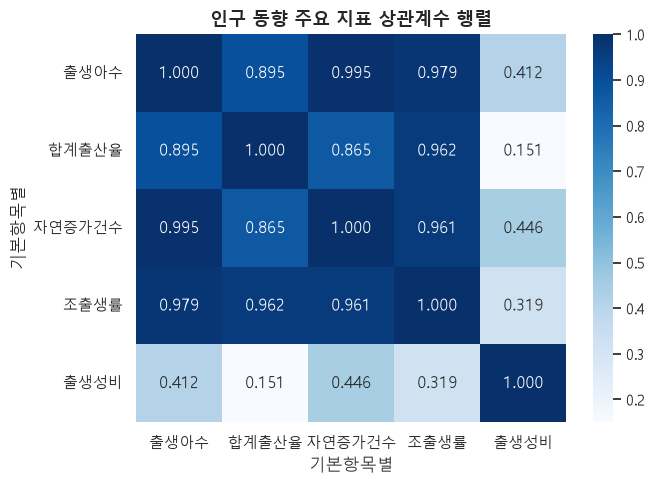

In [10]:
corr = df[["출생아수", "합계출산율", "자연증가건수", "조출생률", "출생성비"]].corr().round(3)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".3f", cbar=True)
plt.title("인구 동향 주요 지표 상관계수 행렬", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. 시각화 (1) - 연도별 출생아수 라인 그래프 (요청 메인 시각화)
- 1970년부터 2023년까지 출생아수(만 명) 변화 추이를 선 그래프로 시각화합니다.
- 주요 구간 기준선(100만, 70만, 50만, 30만) 및 변곡점 어노테이션(Annotation)을 배치합니다.

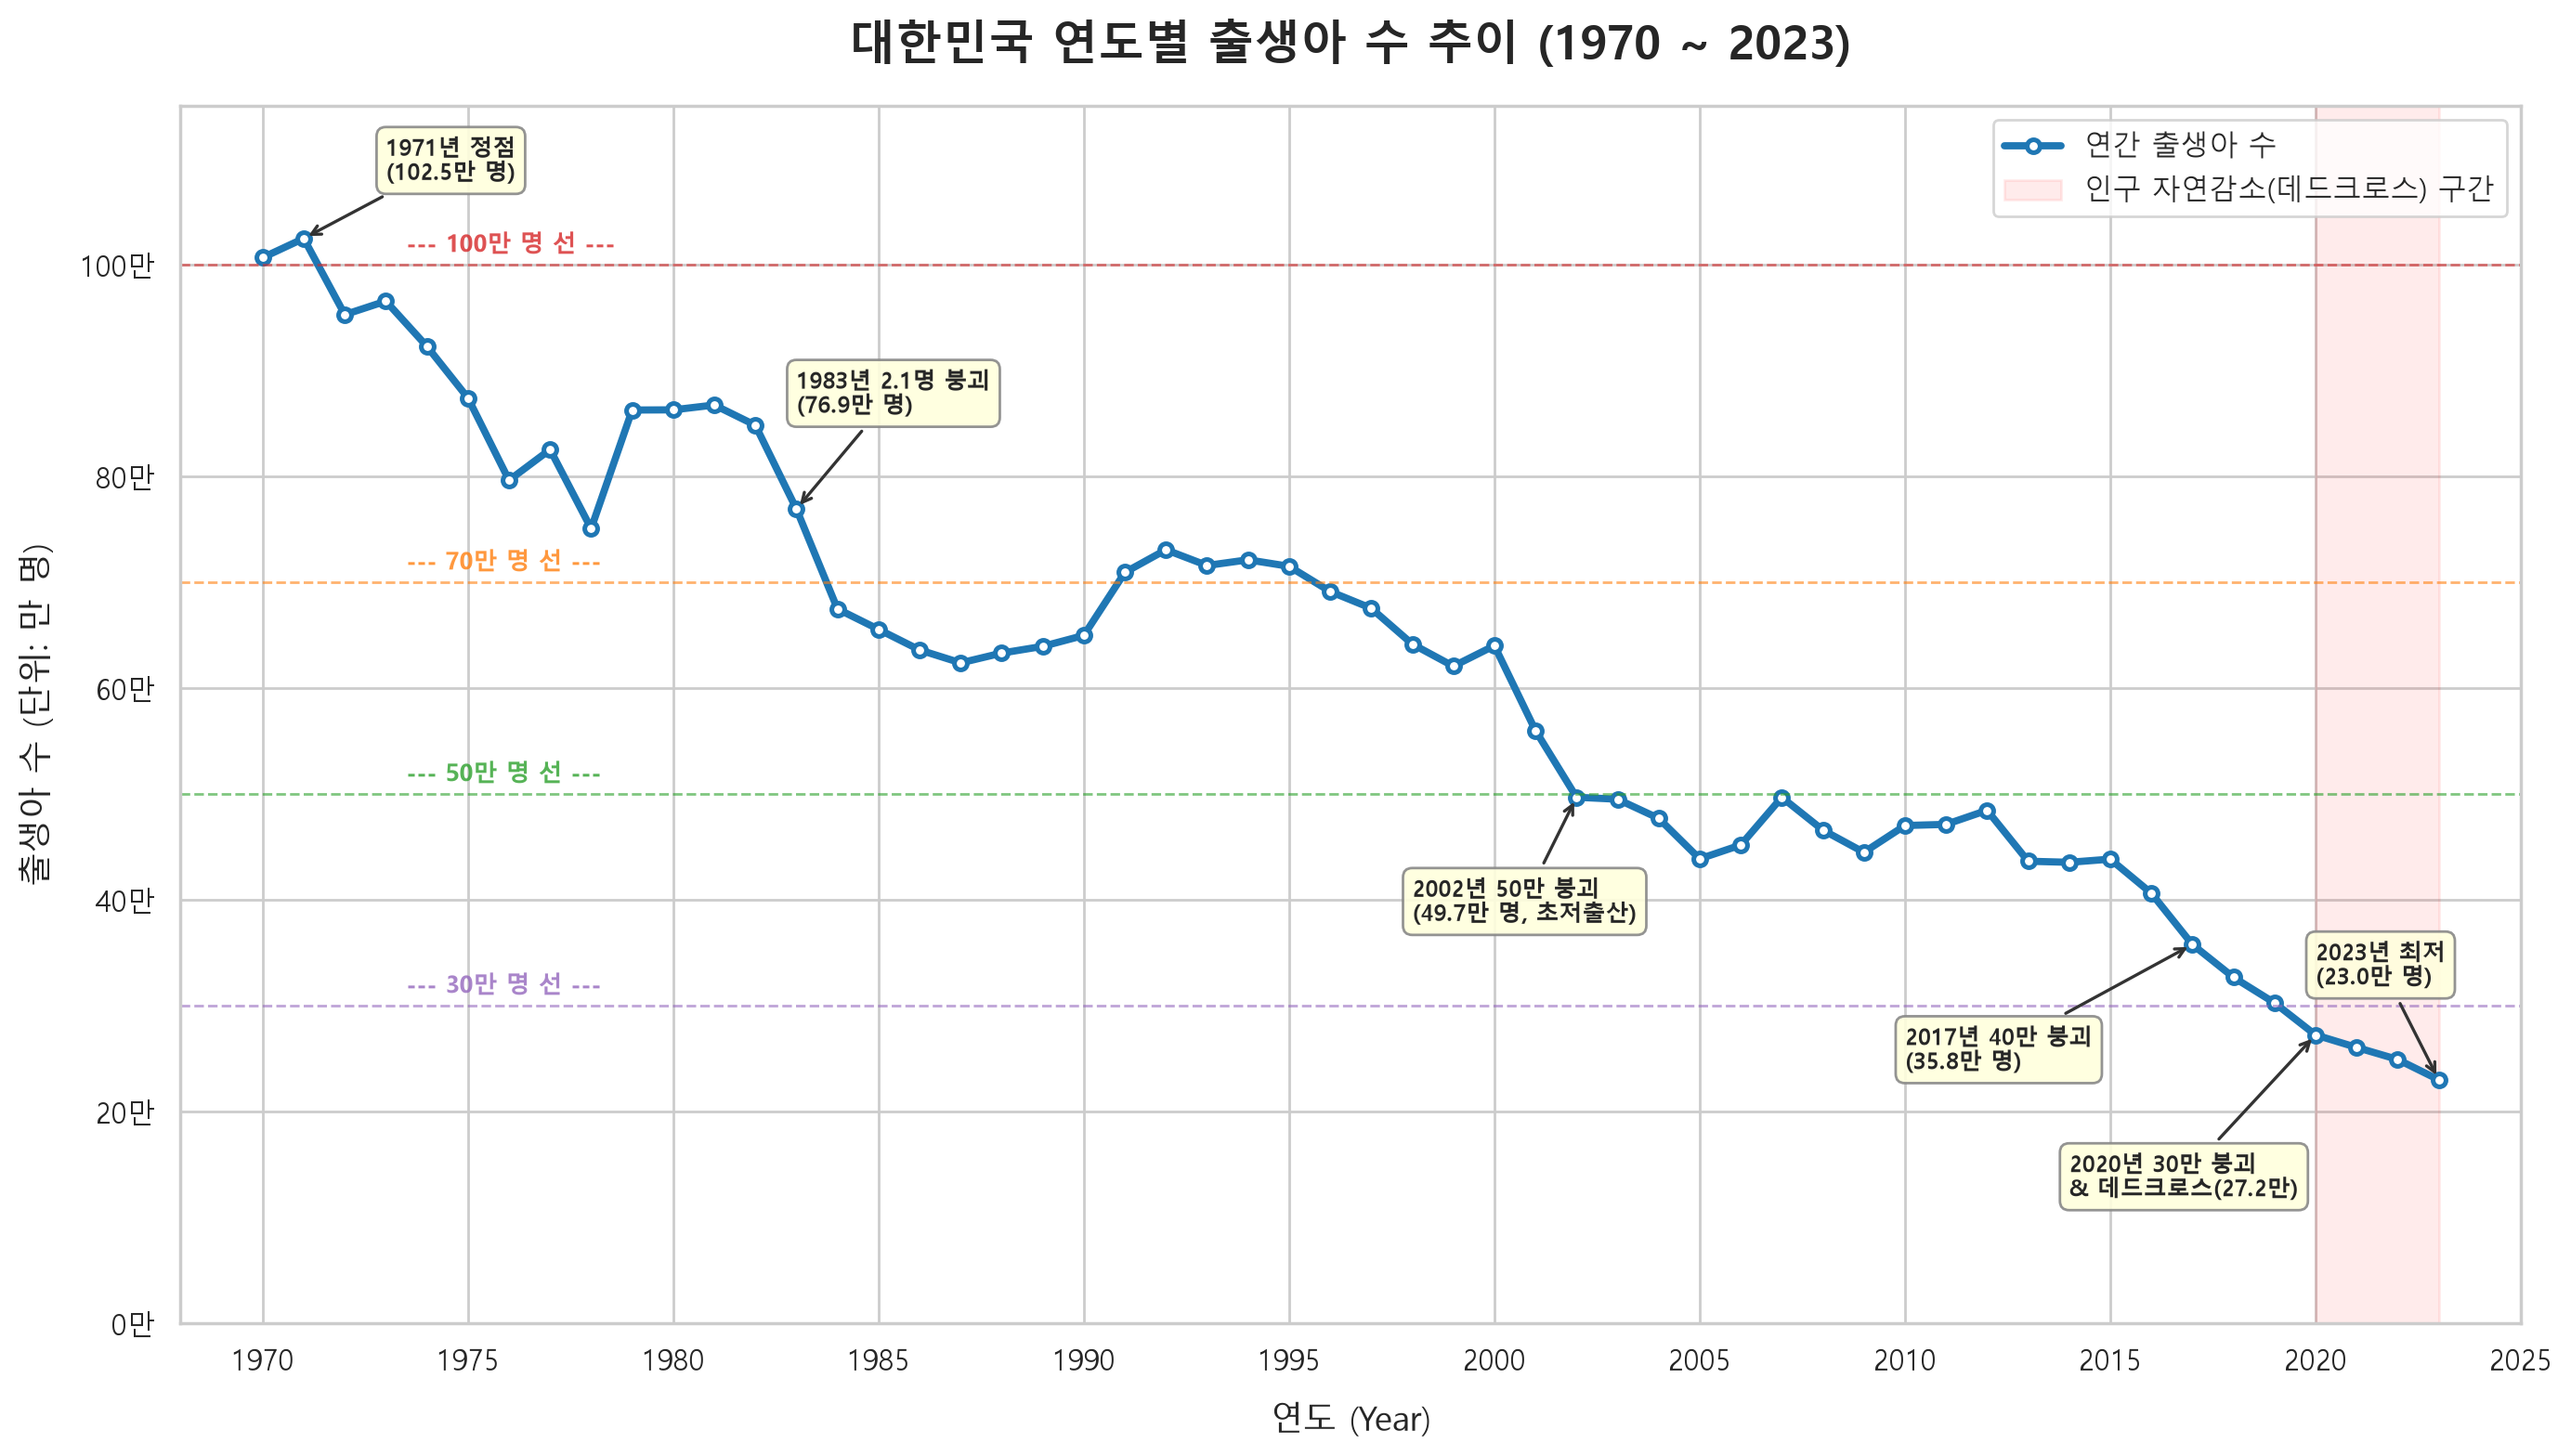

In [11]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=200)

# 라인 및 마커 플롯
ax.plot(df.index, df["출생아수_만명"], color="#1f77b4", linewidth=2.8, 
        marker="o", markersize=5, markerfacecolor="white", markeredgewidth=1.8, markeredgecolor="#1f77b4", 
        label="연간 출생아 수")

# 기준선 (100만, 70만, 50만, 30만)
milestone_lines = [100, 70, 50, 30]
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#9467bd"]
for m, c in zip(milestone_lines, colors):
    ax.axhline(m, color=c, linestyle="--", linewidth=1.0, alpha=0.6)
    ax.text(1973.5, m + 1.2, f"--- {m}만 명 선 ---", color=c, fontsize=9.5, fontweight="bold", alpha=0.8)

# 주요 마일스톤 주석
annotations = [
    (1971, df.loc[1971, "출생아수_만명"], "1971년 정점\n(102.5만 명)", (1973, 108)),
    (1983, df.loc[1983, "출생아수_만명"], "1983년 2.1명 붕괴\n(76.9만 명)", (1983, 86)),
    (2002, df.loc[2002, "출생아수_만명"], "2002년 50만 붕괴\n(49.7만 명, 초저출산)", (1998, 38)),
    (2017, df.loc[2017, "출생아수_만명"], "2017년 40만 붕괴\n(35.8만 명)", (2010, 24)),
    (2020, df.loc[2020, "출생아수_만명"], "2020년 30만 붕괴\n& 데드크로스(27.2만)", (2014, 12)),
    (2023, df.loc[2023, "출생아수_만명"], "2023년 최저\n(23.0만 명)", (2020, 32))
]

for yr, val, text, xytext in annotations:
    ax.annotate(text, xy=(yr, val), xytext=xytext,
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.2),
                fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", fc="#ffffdd", ec="#888888", lw=1.0, alpha=0.9))

# 2020년 이후 인구감소 구간 음영
ax.axvspan(2020, 2023, color="red", alpha=0.08, label="인구 자연감소(데드크로스) 구간")

ax.set_title("대한민국 연도별 출생아 수 추이 (1970 ~ 2023)", fontsize=18, fontweight="bold", pad=18)
ax.set_xlabel("연도 (Year)", fontsize=13, labelpad=10)
ax.set_ylabel("출생아 수 (단위: 만 명)", fontsize=13, labelpad=10)
ax.set_xlim(1968, 2025)
ax.set_ylim(0, 115)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x)}만"))
ax.legend(loc="upper right", fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig("birth_trend_line_chart.png", dpi=300)
plt.show()

## 6. 시각화 (2) - 다각도 종합 분석 대시보드 (2x2 서브플롯)
1. **출생아수 vs 합계출산율 이중 축 시계열 (Twin-X)**
2. **연도별 인구 자연증가건수 (2020년 데드크로스 음수 영역 가시화)**
3. **연대별(10년 단위) 평균 지표 비교**
4. **출생성비(여아 100명당 남아 수) 정상화 추이**

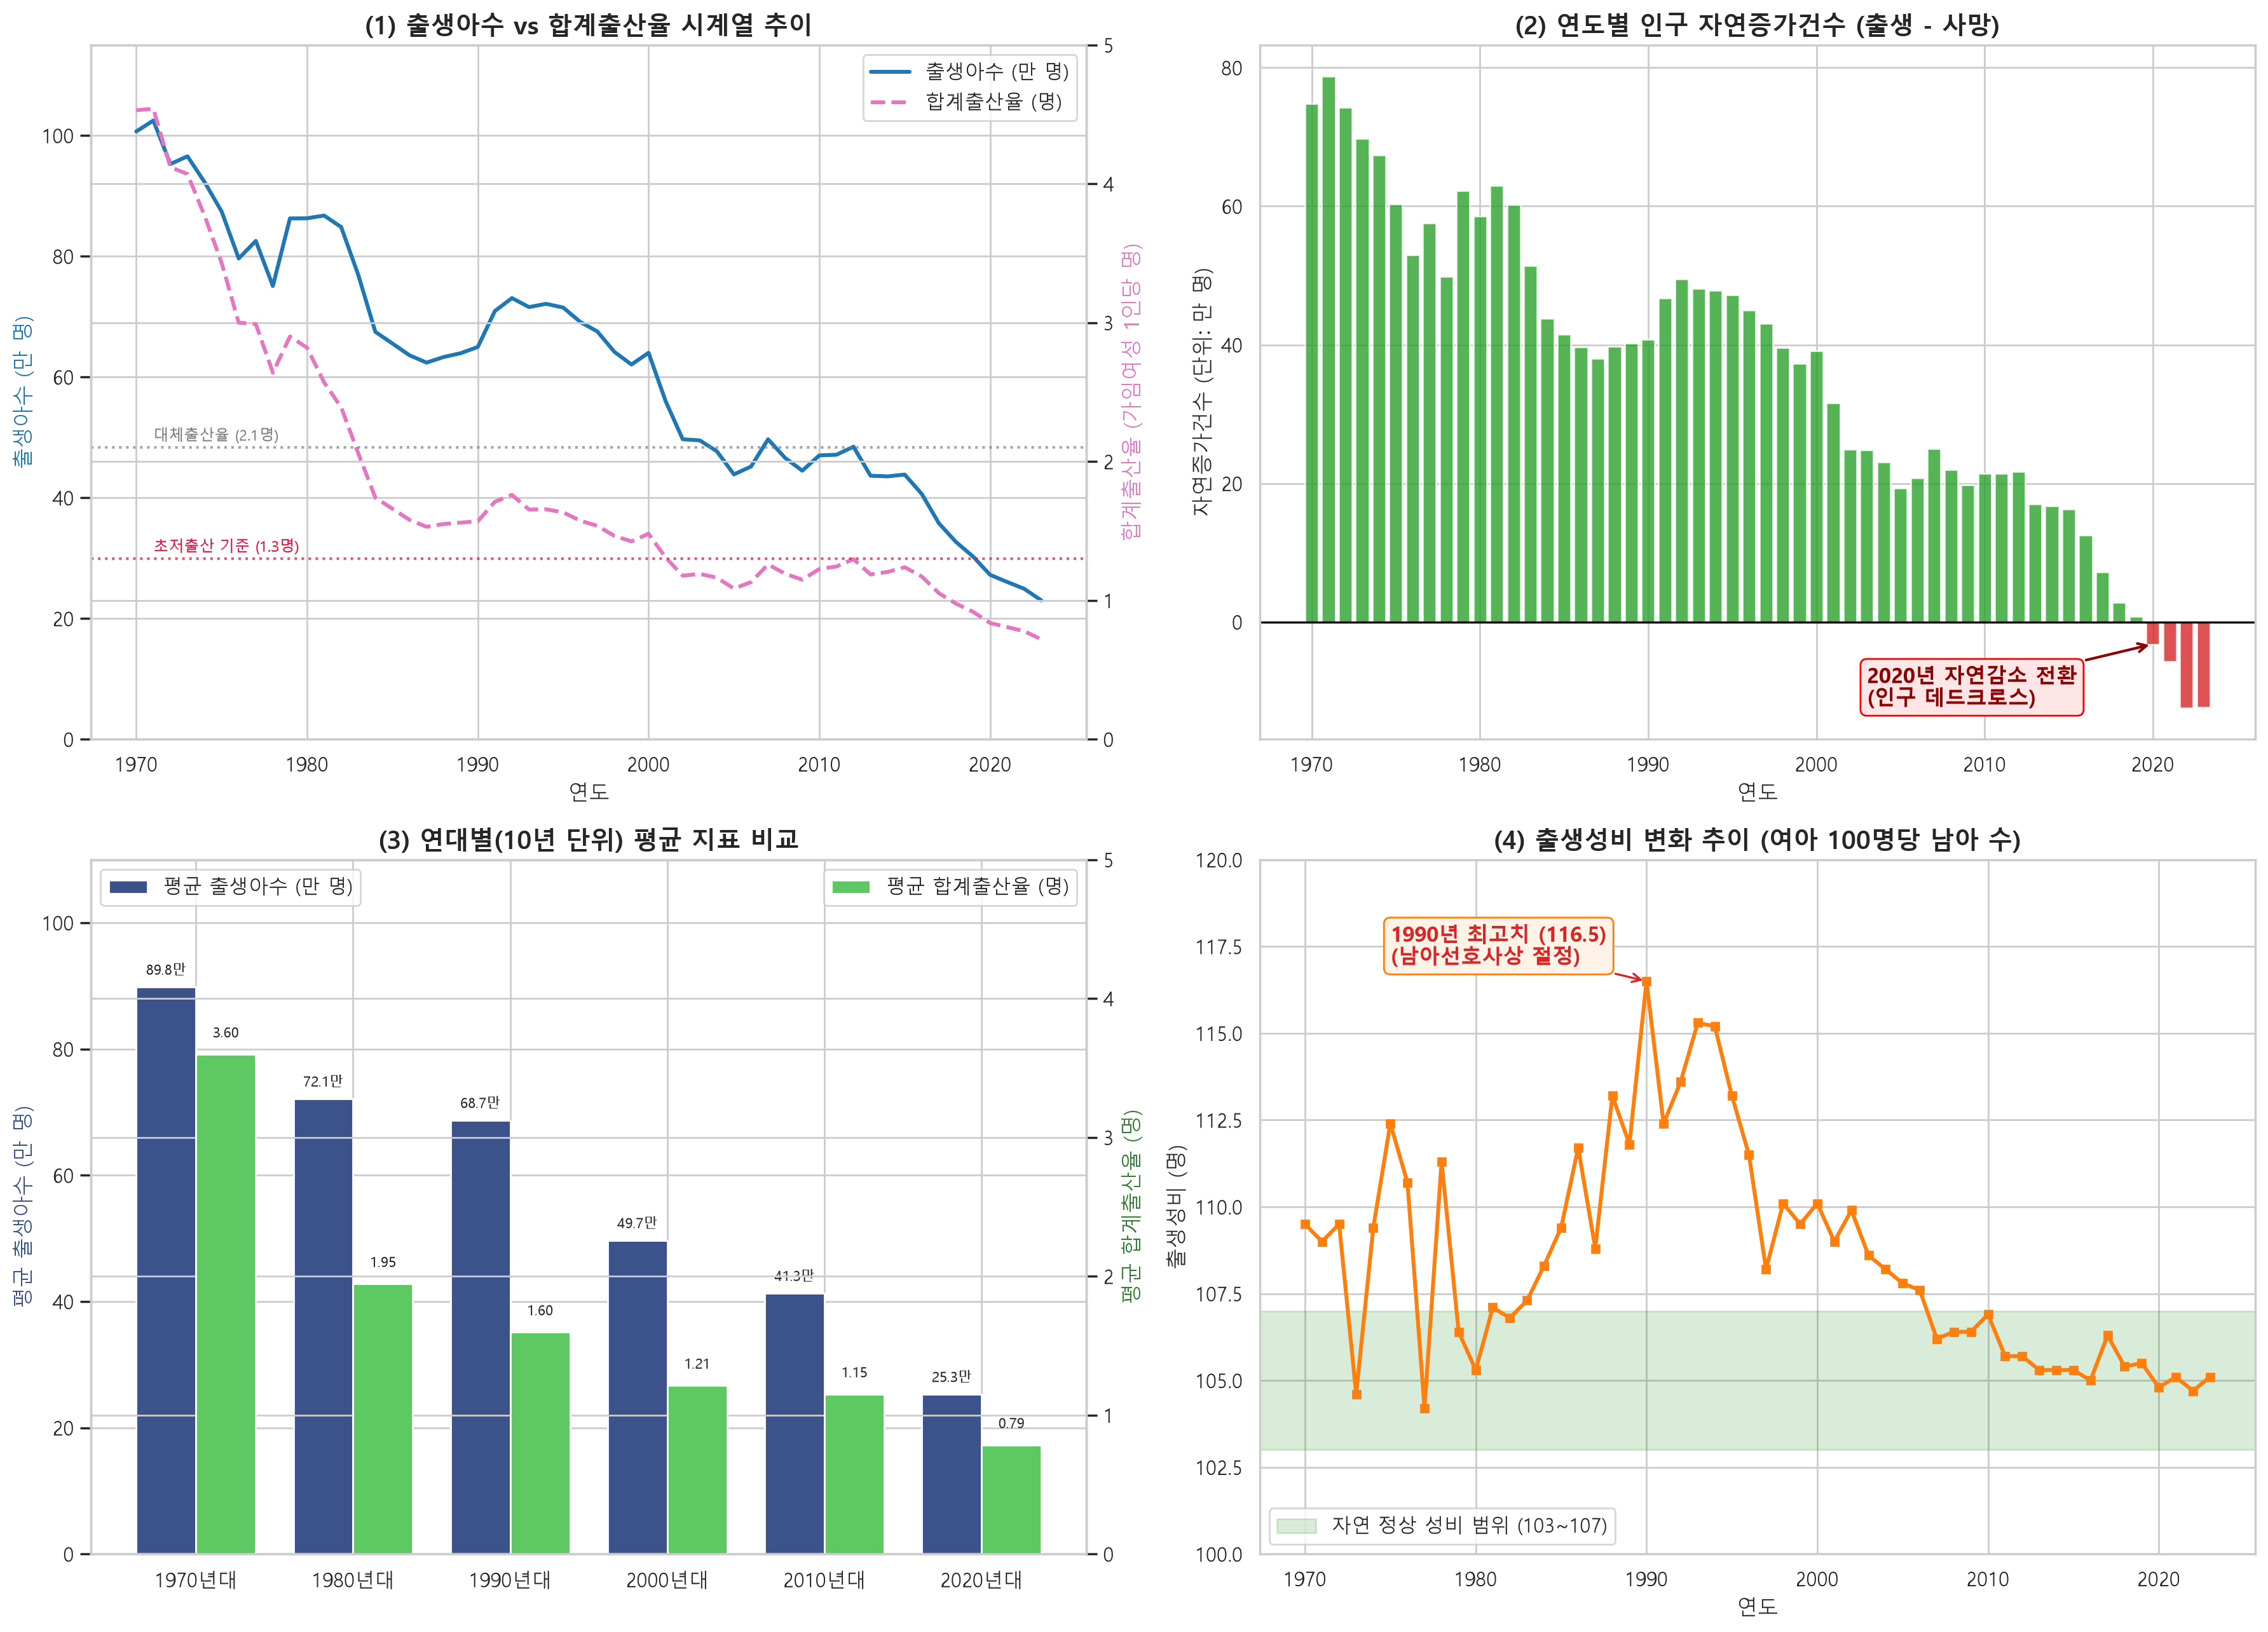

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13), dpi=200)

# (1) 출생아수 vs 합계출산율 이중 축 시계열 (Twin-X)
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
l1 = ax1.plot(df.index, df["출생아수_만명"], color="#1f77b4", lw=2.2, label="출생아수 (만 명)")
l2 = ax1_twin.plot(df.index, df["합계출산율"], color="#e377c2", lw=2.2, linestyle="--", label="합계출산율 (명)")
ax1_twin.axhline(2.1, color="gray", linestyle=":", alpha=0.7)
ax1_twin.text(1971, 2.15, "대체출산율 (2.1명)", color="gray", fontsize=8.5)
ax1_twin.axhline(1.3, color="crimson", linestyle=":", alpha=0.7)
ax1_twin.text(1971, 1.35, "초저출산 기준 (1.3명)", color="crimson", fontsize=8.5)
ax1.set_title("(1) 출생아수 vs 합계출산율 시계열 추이", fontsize=14, fontweight="bold")
ax1.set_xlabel("연도")
ax1.set_ylabel("출생아수 (만 명)", color="#1f77b4")
ax1_twin.set_ylabel("합계출산율 (가임여성 1인당 명)", color="#e377c2")
ax1.set_ylim(0, 115)
ax1_twin.set_ylim(0, 5.0)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

# (2) 자연증가건수 (인구 데드크로스)
ax2 = axes[0, 1]
nat_inc_man = df["자연증가건수"] / 10000.0
colors_nat = ["#2ca02c" if v >= 0 else "#d62728" for v in nat_inc_man]
ax2.bar(df.index, nat_inc_man, color=colors_nat, width=0.8, alpha=0.8)
ax2.axhline(0, color="black", linewidth=1.2)
ax2.set_title("(2) 연도별 인구 자연증가건수 (출생 - 사망)", fontsize=14, fontweight="bold")
ax2.set_xlabel("연도")
ax2.set_ylabel("자연증가건수 (단위: 만 명)")
ax2.annotate("2020년 자연감소 전환\n(인구 데드크로스)", xy=(2020, -3.2), xytext=(2003, -12),
             arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
             fontweight="bold", color="darkred",
             bbox=dict(boxstyle="round,pad=0.3", fc="#ffe6e6", ec="red", lw=1.0))

# (3) 연대별(10년 단위) 평균 비교
ax3 = axes[1, 0]
decade_df = df.groupby("연대")[["출생아수_만명", "합계출산율"]].mean()
x_idx = np.arange(len(decade_df.index))
width = 0.38
b1 = ax3.bar(x_idx - width/2, decade_df["출생아수_만명"], width, label="평균 출생아수 (만 명)", color="#3b528b")
ax3_twin = ax3.twinx()
b2 = ax3_twin.bar(x_idx + width/2, decade_df["합계출산율"], width, label="평균 합계출산율 (명)", color="#5ec962")
ax3.set_xticks(x_idx)
ax3.set_xticklabels(decade_df.index)
ax3.set_title("(3) 연대별(10년 단위) 평균 지표 비교", fontsize=14, fontweight="bold")
ax3.set_ylabel("평균 출생아수 (만 명)", color="#3b528b")
ax3.set_ylim(0, 110)
ax3_twin.set_ylabel("평균 합계출산율 (명)", color="#2e7d32")
ax3_twin.set_ylim(0, 5.0)
for bar in b1:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.1f}만", ha="center", va="bottom", fontsize=8)
for bar in b2:
    yval = bar.get_height()
    ax3_twin.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}", ha="center", va="bottom", fontsize=8)
ax3.legend(loc="upper left")
ax3_twin.legend(loc="upper right")

# (4) 출생성비 추이
ax4 = axes[1, 1]
ax4.plot(df.index, df["출생성비"], color="#ff7f0e", lw=2.2, marker="s", markersize=4)
ax4.axhspan(103, 107, color="green", alpha=0.15, label="자연 정상 성비 범위 (103~107)")
ax4.annotate("1990년 최고치 (116.5)\n(남아선호사상 절정)", xy=(1990, 116.5), xytext=(1975, 117),
             arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.2),
             fontweight="bold", color="#d62728",
             bbox=dict(boxstyle="round,pad=0.3", fc="#fff2e6", ec="#ff7f0e", lw=1.0))
ax4.set_title("(4) 출생성비 변화 추이 (여아 100명당 남아 수)", fontsize=14, fontweight="bold")
ax4.set_xlabel("연도")
ax4.set_ylabel("출생성비 (명)")
ax4.set_ylim(100, 120)
ax4.legend(loc="lower left")

plt.tight_layout()
plt.savefig("demographic_comprehensive_charts.png", dpi=300)
plt.show()

## 7. 종합 분석 결과 및 시사점 요약
1. **초저출산의 가속화**: 1970년 100.6만 명(합계출산율 4.53명)에서 2023년 23.0만 명(0.72명)으로 각각 **-77.15%**, **-84.11%** 급감했습니다.
2. **인구 대체수준(2.1명) 및 초저출산(1.3명) 기준 붕괴**: 1983년 처음으로 2.1명 선이 무너졌고, 2002년 초저출산(1.18명)에 진입한 후 반등하지 못하고 2018년 세계 최초로 1.0명 미만(0.98명)으로 하락했습니다.
3. **인구 데드크로스(자연감소) 도래**: 2020년부터 사망자수가 출생아수를 초과하여 연간 3만~12만 명 규모의 순감소가 고착화되었습니다.
4. **출생성비의 정상화**: 1990년 116.5명까지 치솟았던 비정상적 남아선호 현상은 2010년대 이후 105 수준으로 복귀하여 자연 성비(103~107) 내로 안착했습니다.